In [ ]:
import numpy as np
from importlib import reload
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import pandas as pd

%matplotlib widget

In [2]:
module_path = Path('..').resolve()
if str(module_path) not in sys.path:
    sys.path.insert(0, str(module_path))

# Introduction

This noebook shows how to use mcmc_libs to build your own MCMC routine using an emulator in an interactive way in notebooks.

First import `libs/mcmc_libs`. This contains necessary class & functions for emulator-MCMC related task.

In [60]:
import libs.mcmc_libs as mcmc_libs
import libs.data_libs as data_libs

In [109]:
mcmc_libs = reload(mcmc_libs)
data_libs = reload(data_libs)

Load some data and pick a single object.

To make our life a little bit easier, there is a libs/data_libs that has a catalog class `catalog` that loads all available data in an L4 parquet file, and a `catalog_dataset` class that reads an L4 parquet file with pyarrow.dataset, and only extract a single row with `catalog_dataset.get_row()`. If L4 files are very large and you only need a single object, using `catalog_dataset` might save you a bit memory.

After calling `catalog_dataset.get_row()`, it save attributes to the `catalog_dataset` instance.
Noted these part is only for loading fluxes from data. You don't need this part for MCMC to work.

In [11]:
filename = "../data/hotdog_l4_specz_collate_gals.parq"  # make sure change this yourself
spherex_id = 1663027938116763658
cat = data_libs.catalog_dataset(filename=filename)
cat.get_row(SPHERExRefID=spherex_id)
flux = cat.spec
flux_err = cat.err
zbest = cat.zphot
zbest_err = (cat.zphot_u68-cat.zphot_l68)/2

# Data needed

To fit an actual observation, all you need are `flux`, `flux_err`, `filter_list`.  redshift and redshift error can be used as zprior in MCMC.

To fit a model high resolution SED, you just need `flux`, `flux_lbs` (the wavelength grid of your SED).

In [12]:
# SPHEREx official fiducial_filters.txt
filter_list = "/Users/brianwang76/SPHEREx/SPHEREx-L4-Redshift-Pipeline/redshifts/data/FILTER/SPHEREx_306/fiducial_filters.txt"

In [69]:
# get the central wavelength of SPHEREx filters from a file next to the filter list so we can make plots...
filter_central_wavelengths = filter_list.replace(filter_list.split('/')[-1], 'fiducial_filters_cent_waves.txt')
lamb_obs = np.genfromtxt(filter_central_wavelengths, delimiter=' ')[:,1]

## Creating MCMC instance and fit the flux

Now we can start by creating an mcmc instance, using class `mcmc_libs.emulator_mcmc`.

`config_filename` is optional in this mode; there are default settings saved.  
We can pick an emulator as a starting point to construct this instance.  

In [110]:
# emulator we want to use
emulator_filename = "/Users/brianwang76/SPHEREx/pwang55/prospector_emulator/emulator_outputs/emulator.pt"

emcmc_obj = mcmc_libs.emulator_mcmc(
    # config_filename="../configs/mcmc_config.yaml",
    emulator=emulator_filename,
    filters=filter_list,
)

We can start running MCMC!

`redshift` and `redshift_err` are not necessary, they act as redshift gaussian prior if provided.

In [67]:
emcmc_obj.run_mcmc(
    flux=flux,
    flux_err=flux_err,
    redshift=zbest,
    redshift_err=zbest_err
)

100%|██████████| 5000/5000 [03:40<00:00, 22.72it/s]


By default the MCMC results are saved as `emcmc_obj.results`.  
Lets plot the observed fluxes and MCMC fitted median SED:

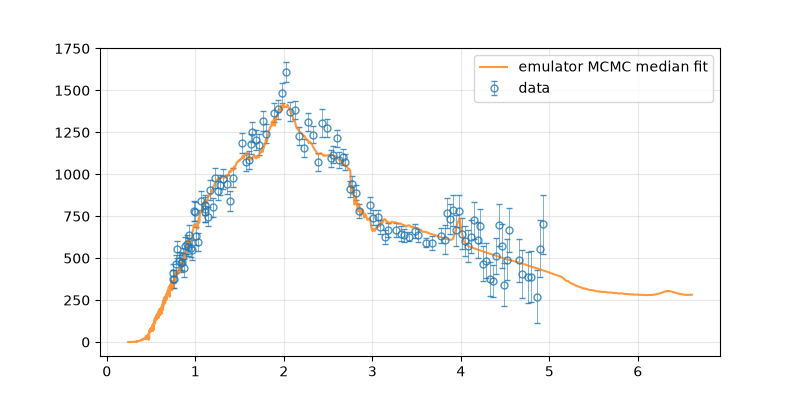

In [83]:
fitted_lbs_med = emcmc_obj.results['lbs_med']
fitted_flux_med = emcmc_obj.results['flux_med']
# fitted_flux_med_conv = emcmc_obj.results['flux_med_conv']


plt.close()
fig, ax = plt.subplots(figsize=(8, 4))

hasflux = flux_err != 50000.0

ax.errorbar(lamb_obs[hasflux], flux[hasflux], flux_err[hasflux], 
            fmt='o', markersize=5, elinewidth=0.5, markerfacecolor='none', markeredgewidth=1.0, capsize=2, alpha=0.8, label="data")
ax.plot(fitted_lbs_med, fitted_flux_med, linewidth=1.5, alpha=0.8, label="emulator MCMC median fit")
# ax.plot(lamb_obs, fitted_flux_med_conv)
ax.grid(alpha=0.3)
ax.legend()

Other available results saved in `results`

In [79]:
list(emcmc_obj.results.keys())

['flat_samples',
 'flat_mfracs',
 'theta_percentiles',
 'lbs_rest',
 'lbs_med',
 'flux_med',
 'flux_med_conv',
 'mfrac_med',
 'mfracs_percentiles',
 'agebins_med',
 'massbins_med',
 'sfrs_med',
 'free_param_keys',
 'fixed_param_keys',
 'fixed_param_vals',
 'autocorr']

### saving result to .h5 file

In [ ]:
emcmc_obj.save_results()

## That's it!

Though there are a lot more functionality packed in the class. It is written to be as flexible as possible.  
Here are some examples of what it can do.

## MCMC settings

You can check the default settings for MCMC with `.current_settings()`:

In [84]:
emcmc_obj.current_settings()

nwalkers: 32
nsteps: 5000
jitter: 0.0001
discard: 2000
thin: 10
zprior: True
save_sampler: False
save_plots: False

current prior:
{'zred': {'init': 0.1, 'bounds': [0.0, 3.0], 'prior': {'dist': 'uniform'}},
 'logmass': {'init': 10.0, 'bounds': [7.5, 13.5], 'prior': {'dist': 'uniform'}},
 'logzsol': {'init': 0.0, 'bounds': [-2.0, 0.2], 'prior': {'dist': 'uniform'}},
 'logsfr_ratios': {'init': 0.0,
                   'bounds': [-5.0, 5.0],
                   'prior': {'dist': 'student_t',
                             'df': 2,
                             'loc': 0.0,
                             'scale': 0.3}},
 'dust2': {'init': 0.3,
           'bounds': [0.0, 4.0],
           'prior': {'dist': 'truncnorm', 'loc': 0.3, 'scale': 1.0}},
 'dust_index': {'init': -1.0,
                'bounds': [-1.2, 0.4],
                'prior': {'dist': 'uniform'}},
 'duste_qpah': {'init': 2.0,
                'bounds': [0.0, 7.0],
                'prior': {'dist': 'truncnorm', 'loc': 2.0, 'scale': 2.0}}}

## One time change to MCMC settings for a run

`run_mcmc()` takes many arguments listed above that allows you to temporarily overide default settings for a specific run.  
This might be useful if you just want to quickly do another MCMC run with different settings.

In [ ]:
emcmc_obj.run_mcmc?

Signature:
emcmc_obj.run_mcmc(
    flux,
    flux_err=None,
    flux_lbs=None,
    filters=None,
    redshift=None,
    redshift_err=None,
    initial=None,
    nwalkers=None,
    jitter=None,
    nsteps=None,
    zprior=None,
    discard=None,
    thin=None,
    prior=None,
    save_sampler=None,
    sampler_filename=None,
    verbose=None,
    parallel=None,
    n_processes=None,
    results=True,
)
Docstring: <no docstring>
File:      ~/SPHEREx/pwang55/prospector_emulator/libs/mcmc_libs.py
Type:      method

In [ ]:
emcmc_obj.run_mcmc(
    flux=flux,
    flux_err=flux_err,
    redshift=zbest,
    redshift_err=zbest_err,
    nsteps=3000,
    discard=1000,
    thin=10
)
# 

100%|██████████| 3000/3000 [02:02<00:00, 24.53it/s]


## Parameter prior settings

`emcmc_obj.current_settings()` also listed the priors for parameters including bounds, distribution and initial value.  
You can give a user prior in each `emcmc_obj.run_mcmc()` runs, by using a scratchpad prior attribute called `emcmc_obj.user_prior`:

In [111]:
emcmc_obj.user_prior

{'zred': {'init': 0.1, 'bounds': [0.0, 3.0], 'prior': {'dist': 'uniform'}},
 'logmass': {'init': 10.0,
  'bounds': [7.5, 13.5],
  'prior': {'dist': 'uniform'}},
 'logzsol': {'init': 0.0, 'bounds': [-2.0, 0.2], 'prior': {'dist': 'uniform'}},
 'logsfr_ratios': {'init': 0.0,
  'bounds': [-5.0, 5.0],
  'prior': {'dist': 'student_t', 'df': 2, 'loc': 0.0, 'scale': 0.3}},
 'dust2': {'init': 0.3,
  'bounds': [0.0, 4.0],
  'prior': {'dist': 'truncnorm', 'loc': 0.3, 'scale': 1.0}},
 'dust_ratio': {'init': 1.0,
  'bounds': [0.0, 2.0],
  'prior': {'dist': 'truncnorm', 'loc': 1.0, 'scale': 1.0}},
 'dust_index': {'init': -1.0,
  'bounds': [-1.2, 0.4],
  'prior': {'dist': 'uniform'}},
 'duste_qpah': {'init': 2.0,
  'bounds': [0.0, 7.0],
  'prior': {'dist': 'truncnorm', 'loc': 2.0, 'scale': 2.0}},
 'log10_duste_gamma': {'init': -2.0,
  'bounds': [-4.0, 0.0],
  'prior': {'dist': 'truncnorm', 'loc': -2.0, 'scale': 2.0}},
 'duste_umin': {'init': 1.0,
  'bounds': [0.1, 25.0],
  'prior': {'dist': 'truncnor

Lets change `dust2` bound to be [0.0, 3.0], and fix redshift to 0.204, the zspec of this particular object.  
You modify `emcmc_obj.user_prior`, then give it to `emcmc_obj.run_mcmc(prior=emcmc_obj.user_prior)`.   
If you don't supply prior to run_mcmc, it will still use default prior.

In [112]:
emcmc_obj.user_prior['dust2']['bounds'] = [0.0, 3.0]    # change prior parameters
emcmc_obj.user_prior['zred']['fixed'] = 0.204

emcmc_obj.run_mcmc(
    flux=flux,
    flux_err=flux_err,
    prior=emcmc_obj.user_prior,     # has to be provided here !!!
    nsteps=3000,
    discard=1000,
    thin=10
)

100%|██████████| 3000/3000 [02:14<00:00, 22.35it/s]


## Fit to a high resolution SED

You can use this tool to fit a hig resolution SED like templates etc.  
In this case, you don't need to supply `flux_err`, and instead provide `run_mcmc()` with `flux_lbs` (the wavelength grid of your spectra)  

Make sure to set `filters=False` to turn off filter convolution! if you don't, default filters will still be used.

In [114]:
lbs_example = np.arange(0.2, 5.5, 0.01)
flux = np.random.normal(len(lbs_example))   # I don't have a good example of spectra so just showing syntax here
emcmc_obj.run_mcmc(
    flux=flux,
    flux_lbs=lbs_example,
    filters=False,
    nsteps=3000,
)


100%|██████████| 3000/3000 [00:43<00:00, 68.61it/s]


## Swapping emulator

If you want to try a different emulator.pt, simply change `self.emulator = new_emulator`  

Although this new_emulator has to be a pre-loaded emulator from `libs/emulator_libs.py` `LoadedSPSEmulator` class